In [1]:
import os,sys
sys.path.append(os.path.abspath(os.path.join(os.path.dirname('utils'), '..')))
from module.utils import * 
from module.prompt import * 
from module.custom_model import *
from module.base_model import *
from module.tools import *

In [2]:
start_langsmith('test_01')

LangSmith 추적을 시작합니다.
[프로젝트명]
test_01


In [3]:
from typing import TypedDict, Annotated, List, Literal,Tuple
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import AIMessage,HumanMessage,SystemMessage,ToolMessage
from langgraph.prebuilt import create_react_agent
from langchain_core.tools import tool
from langchain_core.runnables import RunnableLambda, RunnableWithFallbacks

In [4]:
########## 1. 상태 정의 ##########
class State(TypedDict):
    # 메시지 목록 주석 추가
    messages: Annotated[list, add_messages]

In [5]:
@tool
def sum_tools(a:int, b:int)->int:
    """ get a, b  two number add"""
    return a+b

# tavily_tool = get_tavily_tool()
tools = [sum_tools]
# LLM 초기화
llm = get_gemini()
# 도구와 LLM 결합
llm_with_tools = llm.bind_tools(tools)


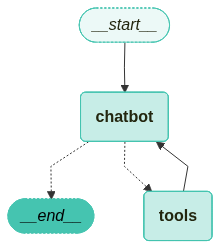

In [6]:


########## 3. 노드 추가 ##########
# 챗봇 함수 정의
def chatbot(state: State):
    # 메시지 호출 및 반환
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


# 상태 그래프 생성
state_graph = StateGraph(State)

# 챗봇 노드 추가
state_graph.add_node("chatbot", chatbot)


# 도구 노드 생성 및 추가
tool_node = ToolNode(tools=tools)

# 도구 노드 추가
state_graph.add_node("tools", tool_node)

# 조건부 엣지
state_graph.add_conditional_edges(
    "chatbot",
    tools_condition,
)

########## 4. 엣지 추가 ##########

# tools > chatbot
state_graph.add_edge("tools", "chatbot")

# START > chatbot
state_graph.add_edge(START, "chatbot")

# chatbot > END
state_graph.add_edge("chatbot", END)

########## 5. MemorySaver 추가 ##########

# 메모리 저장소 초기화
memory = MemorySaver()

########## 6. interrupt_before 추가 ##########

# 그래프 빌더 컴파일
graph = state_graph.compile(checkpointer=memory)

########## 7. 그래프 시각화 ##########
# 그래프 시각화
visualize_graph(graph)

## 실행부

### 그래프 실행 시작

In [7]:
question = "1 +10  은?"
config = get_runnable_config(recursion_limit=10,thread_id=get_random_uuid())
# invoke_graph(graph,{'messages':question},config)

In [8]:
for event in graph.stream(
    input={'messages':question},
    config=config,
    stream_mode="values",
    interrupt_before=["tools"],  # tools 실행 전 interrupt(tools 노드 실행 전 중단)
):
    for key, value in event.items():
        # key 는 노드 이름
        print(f"\n[{key}]\n")

        # value 는 노드의 출력값
        print(value)
        

        # value 에는 state 가 dict 형태로 저장(values 의 key 값)
        if "messages" in value:
            print(f"메시지 개수: {len(value['messages'])}")


[messages]

[HumanMessage(content='1 +10  은?', additional_kwargs={}, response_metadata={}, id='2dcea4b7-4473-46ca-9061-8613b74b1e2f')]

[messages]

[HumanMessage(content='1 +10  은?', additional_kwargs={}, response_metadata={}, id='2dcea4b7-4473-46ca-9061-8613b74b1e2f'), AIMessage(content='', additional_kwargs={'function_call': {'name': 'sum_tools', 'arguments': '{"b": 10, "a": 1}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': []}, id='run--96aef783-2d38-45b2-b8ee-5b0f53b4511d-0', tool_calls=[{'name': 'sum_tools', 'args': {'b': 10, 'a': 1}, 'id': 'ad9ec614-e71d-4d3a-aad4-0a060f90a34d', 'type': 'tool_call'}], usage_metadata={'input_tokens': 59, 'output_tokens': 21, 'total_tokens': 80, 'input_token_details': {'cache_read': 0}})]


### snapshot


In [9]:
# 그래프 상태 스냅샷 생성
snapshot = graph.get_state(config)

# 다음 스냅샷 상태
orgin_messages = snapshot.values['messages'][-1]

new_messages = orgin_messages.tool_calls[0]

new_messages['args']={'a':100,'b':1000}
print ( orgin_messages )
# {'name': 'sum_tools', 'args': {'a': 1, 'b': 10}, 'id': '9c3a4bb7-92ee-41dc-84a1-81e5e8ebf2ff', 'type': 'tool_call'}
print ( new_messages )
# {'name': 'sum_tools', 'args': {'a': 100, 'b': 1000}, 'id': '9c3a4bb7-92ee-41dc-84a1-81e5e8ebf2ff', 'type': 'tool_call'}
_new_messages = [
    AIMessage(
        content=orgin_messages.content,
        tool_calls=[new_messages],
        id = orgin_messages.id
    )
]
graph.update_state(
    # 업데이트할 상태 지정
    config,
    # 제공할 업데이트된 값. `State`의 메시지는 "추가 전용"으로 기존 상태에 추가됨
    {"messages": _new_messages},
)

content='' additional_kwargs={'function_call': {'name': 'sum_tools', 'arguments': '{"b": 10, "a": 1}'}} response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': []} id='run--96aef783-2d38-45b2-b8ee-5b0f53b4511d-0' tool_calls=[{'name': 'sum_tools', 'args': {'a': 100, 'b': 1000}, 'id': 'ad9ec614-e71d-4d3a-aad4-0a060f90a34d', 'type': 'tool_call'}] usage_metadata={'input_tokens': 59, 'output_tokens': 21, 'total_tokens': 80, 'input_token_details': {'cache_read': 0}}
{'name': 'sum_tools', 'args': {'a': 100, 'b': 1000}, 'id': 'ad9ec614-e71d-4d3a-aad4-0a060f90a34d', 'type': 'tool_call'}


{'configurable': {'thread_id': '78e7c015-f661-4297-8e2c-a44076574ff5',
  'checkpoint_ns': '',
  'checkpoint_id': '1f0a0f34-f32c-6d13-8002-e2dc79d70e4b'}}

In [10]:
snapshot = graph.get_state(config)
print(snapshot)

StateSnapshot(values={'messages': [HumanMessage(content='1 +10  은?', additional_kwargs={}, response_metadata={}, id='2dcea4b7-4473-46ca-9061-8613b74b1e2f'), AIMessage(content='', additional_kwargs={}, response_metadata={}, id='run--96aef783-2d38-45b2-b8ee-5b0f53b4511d-0', tool_calls=[{'name': 'sum_tools', 'args': {'a': 100, 'b': 1000}, 'id': 'ad9ec614-e71d-4d3a-aad4-0a060f90a34d', 'type': 'tool_call'}])]}, next=('tools',), config={'configurable': {'thread_id': '78e7c015-f661-4297-8e2c-a44076574ff5', 'checkpoint_ns': '', 'checkpoint_id': '1f0a0f34-f32c-6d13-8002-e2dc79d70e4b'}}, metadata={'source': 'update', 'step': 2, 'parents': {}}, created_at='2025-10-04T07:25:31.471166+00:00', parent_config={'configurable': {'thread_id': '78e7c015-f661-4297-8e2c-a44076574ff5', 'checkpoint_ns': '', 'checkpoint_id': '1f0a0f34-7bf5-6e62-8001-f60d45f0848c'}}, tasks=(PregelTask(id='ba2800f7-b10e-d7cf-a435-3b04da3b51e8', name='tools', path=('__pregel_pull', 'tools'), error=None, interrupts=(), state=None,

### 마지막 메시지 확인

In [ ]:
# 메시지 스냅샷에서 마지막 메시지 추출
# existing_message = snapshot.values["messages"][-1]

# existing_message.tool_calls

### 이어하기

In [11]:
events = graph.stream(None, config, stream_mode="values")
# 이벤트 반복 처리
for event in events:
    # 메시지가 이벤트에 포함된 경우
    print(event)
    print("\n\n")

{'messages': [HumanMessage(content='1 +10  은?', additional_kwargs={}, response_metadata={}, id='2dcea4b7-4473-46ca-9061-8613b74b1e2f'), AIMessage(content='', additional_kwargs={}, response_metadata={}, id='run--96aef783-2d38-45b2-b8ee-5b0f53b4511d-0', tool_calls=[{'name': 'sum_tools', 'args': {'a': 100, 'b': 1000}, 'id': 'ad9ec614-e71d-4d3a-aad4-0a060f90a34d', 'type': 'tool_call'}])]}



{'messages': [HumanMessage(content='1 +10  은?', additional_kwargs={}, response_metadata={}, id='2dcea4b7-4473-46ca-9061-8613b74b1e2f'), AIMessage(content='', additional_kwargs={}, response_metadata={}, id='run--96aef783-2d38-45b2-b8ee-5b0f53b4511d-0', tool_calls=[{'name': 'sum_tools', 'args': {'a': 100, 'b': 1000}, 'id': 'ad9ec614-e71d-4d3a-aad4-0a060f90a34d', 'type': 'tool_call'}]), ToolMessage(content='1100', name='sum_tools', id='77ae6851-9924-4611-8af6-536e6c17df87', tool_call_id='ad9ec614-e71d-4d3a-aad4-0a060f90a34d')]}



{'messages': [HumanMessage(content='1 +10  은?', additional_kwargs={}, respo

### 특정 시점 부터 재시작 replay

In [23]:
to_replay = None

# 상태 기록 가져오기
for state in graph.get_state_history(config):
    # 메시지 수 및 다음 상태 출력
    # print(state.values['messages'])
    # print("\n\n")

    print("메시지 수: ", len(state.values["messages"]), "다음 노드: ", state.next)
    print("-" * 80)
    # 특정 상태 선택 기준: 채팅 메시지 수
    if len(state.values["messages"]) == 2:
        to_replay = state

# 다음 항목의 다음 요소 출력
print(to_replay.next)

# 다음 항목의 설정 정보 출력
print(to_replay.config)


메시지 수:  4 다음 노드:  ()
--------------------------------------------------------------------------------
메시지 수:  3 다음 노드:  ('chatbot',)
--------------------------------------------------------------------------------
메시지 수:  2 다음 노드:  ('tools',)
--------------------------------------------------------------------------------
메시지 수:  2 다음 노드:  ('tools',)
--------------------------------------------------------------------------------
메시지 수:  1 다음 노드:  ('chatbot',)
--------------------------------------------------------------------------------
메시지 수:  0 다음 노드:  ('__start__',)
--------------------------------------------------------------------------------
('tools',)
{'configurable': {'thread_id': '78e7c015-f661-4297-8e2c-a44076574ff5', 'checkpoint_ns': '', 'checkpoint_id': '1f0a0f34-7bf5-6e62-8001-f60d45f0848c'}}


In [24]:
to_replay.values['messages']

[HumanMessage(content='1 +10  은?', additional_kwargs={}, response_metadata={}, id='2dcea4b7-4473-46ca-9061-8613b74b1e2f'),
 AIMessage(content='', additional_kwargs={'function_call': {'name': 'sum_tools', 'arguments': '{"b": 10, "a": 1}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': []}, id='run--96aef783-2d38-45b2-b8ee-5b0f53b4511d-0', tool_calls=[{'name': 'sum_tools', 'args': {'b': 10, 'a': 1}, 'id': 'ad9ec614-e71d-4d3a-aad4-0a060f90a34d', 'type': 'tool_call'}], usage_metadata={'input_tokens': 59, 'output_tokens': 21, 'total_tokens': 80, 'input_token_details': {'cache_read': 0}})]

In [25]:

# `to_replay.config`는 `checkpoint_id`는 체크포인터에 저장된 상태에 해당
for event in graph.stream(None, to_replay.config, stream_mode="values"):
    # 메시지가 이벤트에 포함된 경우
    if "messages" in event:
        # 마지막 메시지 출력
        print(event["messages"][-1])

content='' additional_kwargs={'function_call': {'name': 'sum_tools', 'arguments': '{"b": 10, "a": 1}'}} response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': []} id='run--96aef783-2d38-45b2-b8ee-5b0f53b4511d-0' tool_calls=[{'name': 'sum_tools', 'args': {'b': 10, 'a': 1}, 'id': 'ad9ec614-e71d-4d3a-aad4-0a060f90a34d', 'type': 'tool_call'}] usage_metadata={'input_tokens': 59, 'output_tokens': 21, 'total_tokens': 80, 'input_token_details': {'cache_read': 0}}
content='11' name='sum_tools' id='027dd274-d967-49df-bf3f-a8151af3a78c' tool_call_id='ad9ec614-e71d-4d3a-aad4-0a060f90a34d'
content='1 + 10 = 11입니다.' additional_kwargs={} response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash-lite', 'safety_ratings': []} id='run--a736ea3a-66f2-4460-9f2f-4dd24168fb47-0' usage_metadata={'input_tokens': 96, 'output_t